In [110]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

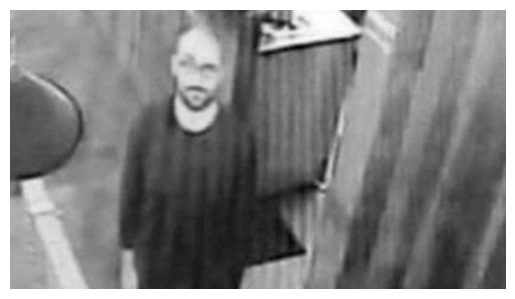

(450, 800)
uint8


In [111]:
backup = cv2.imread("backup.jpg")
backup = cv2.cvtColor(backup, cv2.COLOR_BGR2GRAY)

plt.imshow(backup, cmap='gray')
plt.axis('off')
plt.show()

print(backup.shape)
print(backup.dtype)

In [115]:
def filter(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape

    # ukuran padding / padding size
    pad = size // 2

    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':

            # filter rata-rata / mean filter
            area = size * size

            for i in range(height):
                for j in range(width):

                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # rumus mean manual
                    mean_val = np.sum(region) / area

                    canvas[i, j] = np.uint8(mean_val)

        case 'median':

            # filter median / median filter
            for i in range(height):
                for j in range(width):

                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # rumus median manual
                    values = np.sort(region.ravel())
                    median_val = values[len(values) // 2]

                    canvas[i, j] = np.uint8(median_val)

        case 'modus':

            # filter modus / mode filter
            for i in range(height):
                for j in range(width):

                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]

                    # ratakan array / flatten array
                    values = region.ravel()

                    # hitung kemunculan / count occurrences
                    count = {}

                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    # simpan hasil / save result
                    canvas[i, j] = mode_val

    # kembalikan gambar / return image
    return canvas

In [116]:
# Mean Filter
mean3 = filter(backup, 3, 'mean')

# Median Filter
median3 = filter(backup, 3, 'median')

# Modus Filter
mode3 = filter(backup, 3, 'modus')

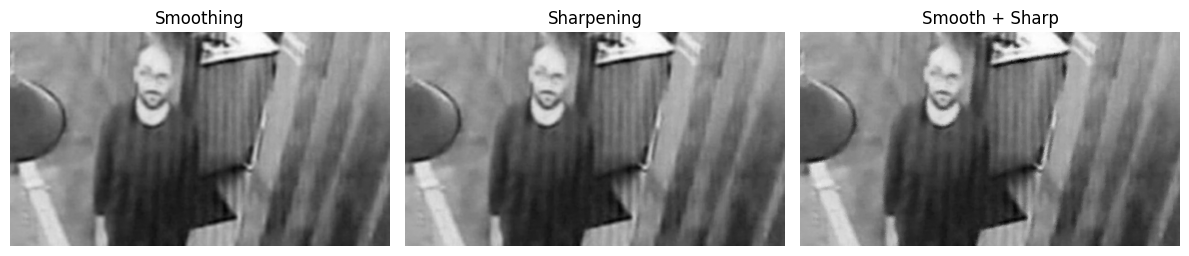

In [117]:
plt.figure(figsize=(12,8))

plt.subplot(1,3,1)
plt.imshow(mean3, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(median3, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(mode3, cmap='gray')
plt.title('Smooth + Sharp')
plt.axis('off')

plt.tight_layout()
plt.show()

In [119]:
def convolution(img, kernel):

    # ukuran kernel / kernel size
    size = kernel.shape[0]

    # ukuran padding / padding size
    pad_size = size // 2

    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)

    # dimensi gambar / image dimensions
    height, width = img.shape

    # loop baris / loop rows
    for i in range(height):

        # loop kolom / loop columns
        for j in range(width):

            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]

            # hitung konvolusi / compute convolution
            conv_value = np.sum(region * kernel)

            # simpan hasil
            canvas[i, j] = conv_value

    # normalisasi ke 0–255 agar aman ditampilkan
    canvas = np.clip(canvas, 0, 255)

    # kembalikan gambar / return image
    return canvas.astype(np.uint8)

In [120]:
# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

# kernel roberts sumbu y / y-axis roberts kernel
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)



In [121]:
prewitt_x = convolution(backup, prewittX)
prewitt_y = convolution(backup, prewittY)

prewitt_result = np.sqrt(
    np.square(prewitt_x.astype(np.float32)) +
    np.square(prewitt_y.astype(np.float32))
)

# normalisasi ke 0–255
prewitt_result = np.clip(prewitt_result, 0, 255)
prewitt_result = prewitt_result.astype(np.uint8)

sobel_x = convolution(backup, sobelX)
sobel_y = convolution(backup, sobelY)

sobel_result = np.sqrt(
    np.square(sobel_x.astype(np.float32)) +
    np.square(sobel_y.astype(np.float32))
)

# normalisasi ke 0–255
sobel_result = np.clip(sobel_result, 0, 255)
sobel_result = sobel_result.astype(np.uint8)

roberts_x = convolution(backup, robertsX)
roberts_y = convolution(backup, robertsY)

roberts_result = np.sqrt(
    np.square(roberts_x.astype(np.float32)) +
    np.square(roberts_y.astype(np.float32))
)

# normalisasi ke 0–255
roberts_result = np.clip(roberts_result, 0, 255)
roberts_result = roberts_result.astype(np.uint8)

# Prewitt + Sobel
prewitt_sobel = np.abs(prewitt_x) + np.abs(prewitt_y) + np.abs(sobel_x) + np.abs(sobel_y)
prewitt_sobel = prewitt_sobel * 255.0 / np.max(prewitt_sobel)
prewitt_sobel = np.clip(prewitt_sobel, 0, 255).astype(np.uint8)

# Prewitt + Roberts
prewitt_roberts = np.abs(prewitt_x) + np.abs(prewitt_y) + np.abs(roberts_x) + np.abs(roberts_y)
prewitt_roberts = prewitt_roberts * 255.0 / np.max(prewitt_roberts)
prewitt_roberts = np.clip(prewitt_roberts, 0, 255).astype(np.uint8)

# Sobel + Roberts
sobel_roberts = np.abs(sobel_x) + np.abs(sobel_y) + np.abs(roberts_x) + np.abs(roberts_y)
sobel_roberts = sobel_roberts * 255.0 / np.max(sobel_roberts)
sobel_roberts = np.clip(sobel_roberts, 0, 255).astype(np.uint8)

# Prewitt + Sobel + Roberts
prewitt_sobel_roberts = np.abs(prewitt_x) + np.abs(prewitt_y) + np.abs(sobel_x) + np.abs(sobel_y) + np.abs(roberts_x) + np.abs(roberts_y)
prewitt_sobel_roberts = prewitt_sobel_roberts * 255.0 / np.max(prewitt_sobel_roberts)
prewitt_sobel_roberts = np.clip(prewitt_sobel_roberts, 0, 255).astype(np.uint8)

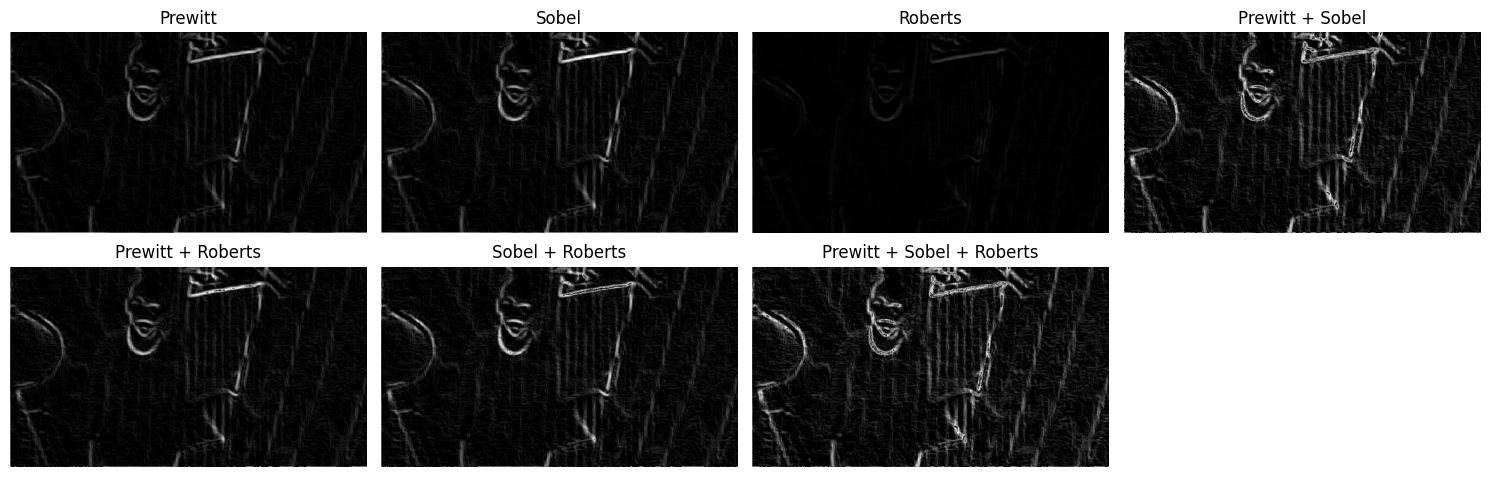

In [122]:
plt.figure(figsize=(15,5))

plt.subplot(2, 4, 1)
plt.imshow(prewitt_result, cmap='gray')
plt.title('Prewitt')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(sobel_result, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(roberts_result, cmap='gray')
plt.title('Roberts')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(prewitt_sobel, cmap='gray')
plt.title('Prewitt + Sobel')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(prewitt_roberts, cmap='gray')
plt.title('Prewitt + Roberts')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(sobel_roberts, cmap='gray')
plt.title('Sobel + Roberts')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(prewitt_sobel_roberts, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')

plt.tight_layout()
plt.show()


In [123]:
def treshold_tepi(img, treshold):
    return (img > treshold).astype(np.uint8) * 255

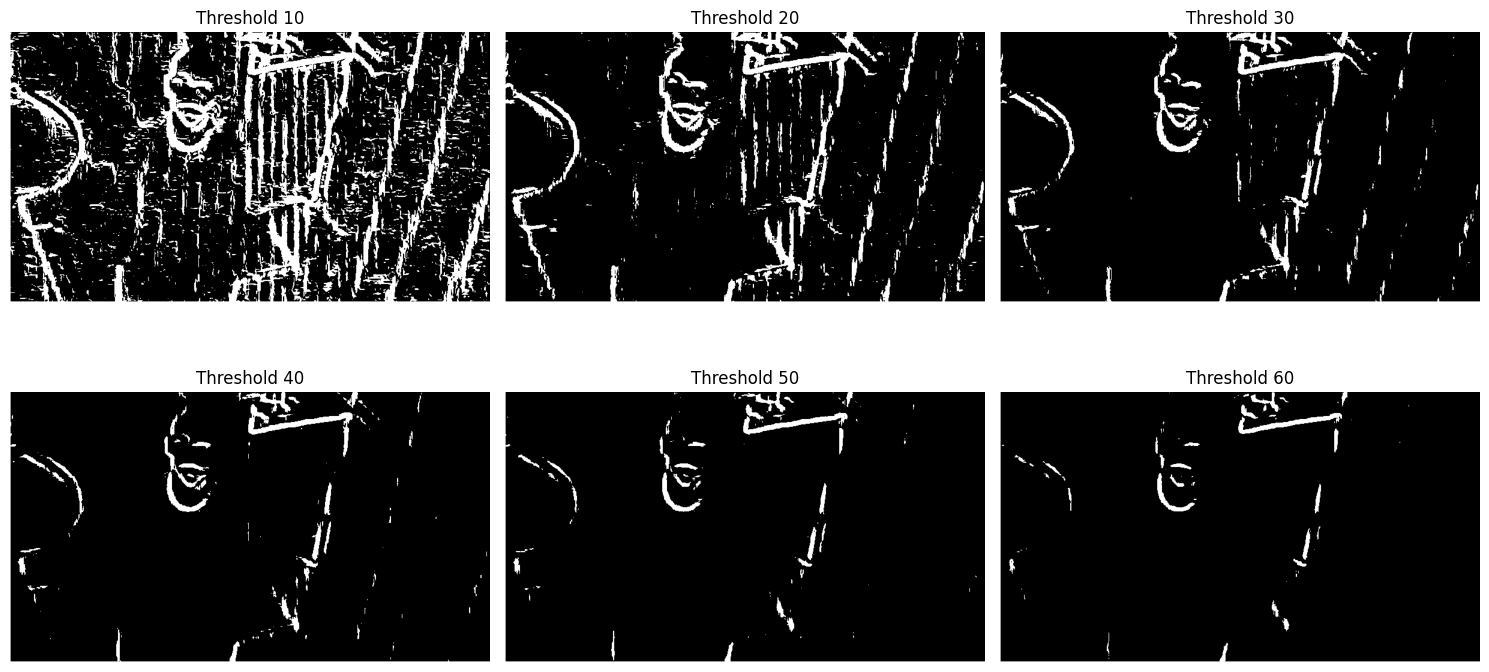

In [124]:
plt.figure(figsize=(15, 8))

# Threshold 10
thresh10 = treshold_tepi(prewitt_result, 10)
plt.subplot(2, 3, 1)
plt.imshow(thresh10, cmap='gray')
plt.title('Threshold 10')
plt.axis('off')

# Threshold 20
thresh20 = treshold_tepi(prewitt_result, 20)
plt.subplot(2, 3, 2)
plt.imshow(thresh20, cmap='gray')
plt.title('Threshold 20')
plt.axis('off')

# Threshold 30
thresh30 = treshold_tepi(prewitt_result, 30)
plt.subplot(2, 3, 3)
plt.imshow(thresh30, cmap='gray')
plt.title('Threshold 30')
plt.axis('off')

# Threshold 40
thresh40 = treshold_tepi(prewitt_result, 40)
plt.subplot(2, 3, 4)
plt.imshow(thresh40, cmap='gray')
plt.title('Threshold 40')
plt.axis('off')

# Threshold 50
thresh50 = treshold_tepi(prewitt_result, 50)
plt.subplot(2, 3, 5)
plt.imshow(thresh50, cmap='gray')
plt.title('Threshold 50')
plt.axis('off')

# Threshold 60
thresh60 = treshold_tepi(prewitt_result, 60)
plt.subplot(2, 3, 6)
plt.imshow(thresh60, cmap='gray')
plt.title('Threshold 60')
plt.axis('off')

plt.tight_layout()
plt.show()

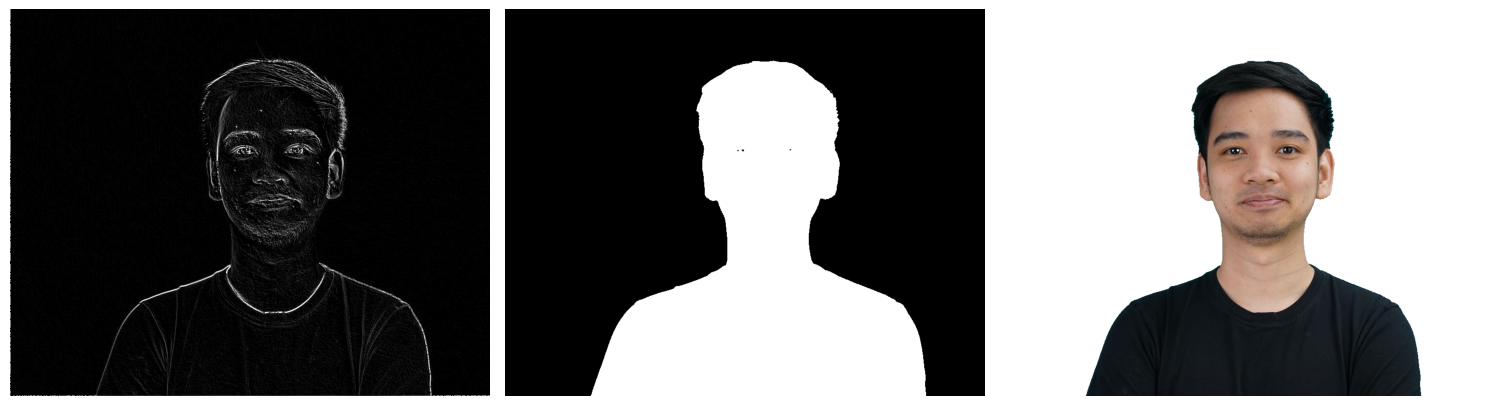

In [ ]:
# load gambar berwarna / load color image
david = cv2.imread("david.jpg")
david_rgb = cv2.cvtColor(david, cv2.COLOR_BGR2RGB)
david_gray = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)

# konvolusi sobel / sobel convolution
sobel_x_david = convolution(david_gray, sobelX)
sobel_y_david = convolution(david_gray, sobelY)

# gabung gradien / combine gradients
sobel_david = np.abs(sobel_x_david) + np.abs(sobel_y_david)
sobel_david = sobel_david * 255.0 / np.max(sobel_david)
sobel_david = np.clip(sobel_david, 0, 255).astype(np.uint8)


# pisahkan kanal RGB 
r = david_rgb[:, :, 0].astype(np.float32)
g = david_rgb[:, :, 1].astype(np.float32)
b = david_rgb[:, :, 2].astype(np.float32)
mask_bg = (g > r) & (b > r) & (g > 80) & (b > 80)

# buat mask foreground
mask_fg = (~mask_bg).astype(np.uint8) * 255

# median filter untuk rapikan mask 
mask_fg = filter(mask_fg, 3, 'median')


# copy gambar / copy image
result = david_rgb.copy()

# background jadi putih / set background to white
result[mask_fg == 0] = [255, 255, 255]


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sobel_david, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_fg, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.axis('off')

plt.tight_layout()
plt.show()